# Single-cell RNA-seq analysis of 3k PBMCs from a Healthy Donor

A reproducible Scanpy workflow on the classic [10x Genomics PBMC3k dataset](https://www.10xgenomics.com/datasets/3-k-pbm-cells-from-a-healthy-donor-v-1-1-1-1-1) (2,700 peripheral blood mononuclear cells, 32,738 genes): **quality control → normalization → dimensionality reduction → clustering → cell-type annotation**.

This notebook is the narrated twin of the standalone script [`pbm3k_scanpy.py`](pbmc3k_scanpy.py) — every code cell below calls a function from that module, so the two can never drift apart. The same steps are also packaged as a **Nextflow pipeline** (`nextflow/main.nf`) with Docker and MultiQC reporting; see the repository `README.md`.


## Setup

```{note}
Run this notebook from its own directory (`analysis/`); the kernel working
directory is used to resolve relative paths. Outputs are written to
`../results/`, shared with the standalone script.
```


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from IPython.display import Image, display

import pbmc3k_scanpy as pl   # the module behind analysis/pbmc3k_scanpy.py

sc.settings.verbosity = 3
sc.set_figure_params(dpi=120, frameon=False)

INPUT = "../data/pbmc3k_raw.h5ad"
OUTDIR = Path("../results")

print(f"scanpy {sc.__version__} | numpy {np.__version__} | pandas {pd.__version__}")


scanpy 1.12.4 | numpy 2.5.2 | pandas 3.0.5


/var/folders/t_/_8g2lwx10wb1h4ddt0321lrm0000gn/T/ipykernel_4489/3817716765.py:18: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f"scanpy {sc.__version__} | numpy {np.__version__} | pandas {pd.__version__}")


## 1. Load the raw expression matrix

The PBMC3k dataset is a raw 10x Genomics gene-barcode count matrix:
2,700 cells × 32,738 genes. `obtain_dataset.py` downloads it into `data/pbmc3k_raw.h5ad`.


In [2]:
adata = sc.read_h5ad(INPUT)
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
    layers: None (.X)

## 2. Quality control

Low-quality cells (few detected genes, extreme library sizes, high mitochondrial
read fraction — a hallmark of dying/lysed cells) and genes detected in almost no
cells are removed. Mitochondrial genes start with `MT-` (13 genes in this dataset).


  wrote ../results/figures/qc_violins_raw.png


Filtering cells and genes


filtered out 5 cells that have more than 2500 genes expressed


filtered out 19082 genes that are detected in less than 3 cells


  wrote ../results/figures/qc_violins_filtered.png


  wrote ../results/tables/qc_metrics.tsv


  wrote ../results/tables/multiqc_scanpy_qc_mqc.json


QC done: 2700 -> 2638 cells, 13656 genes (2.3% of cells removed)


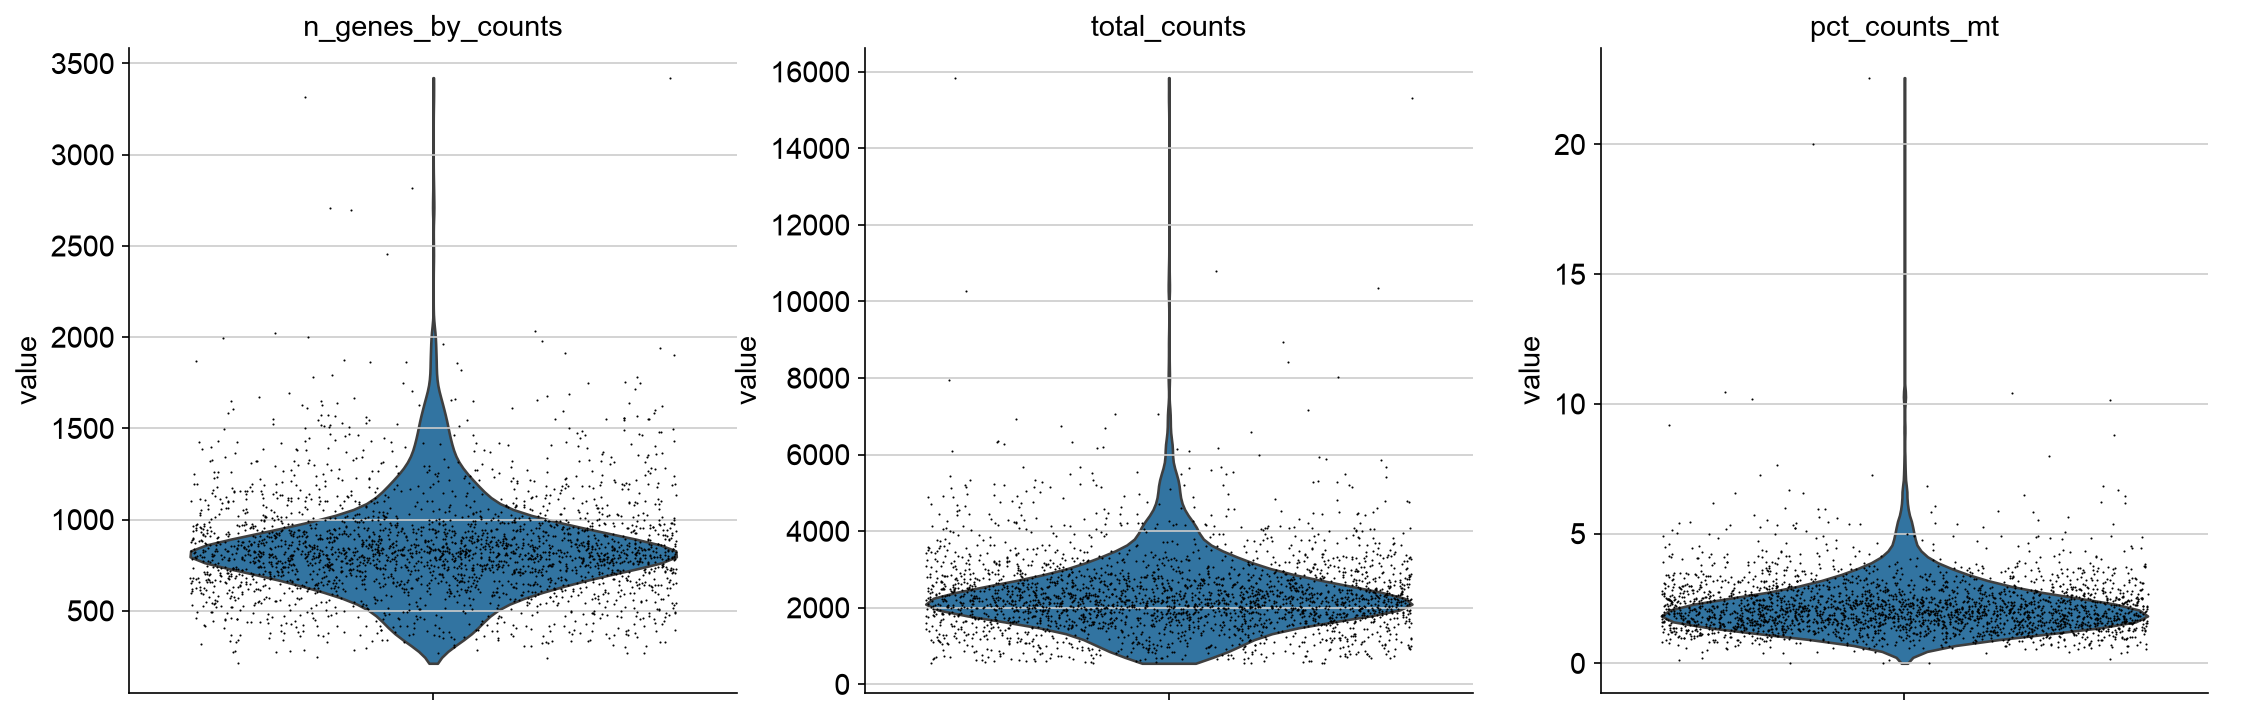

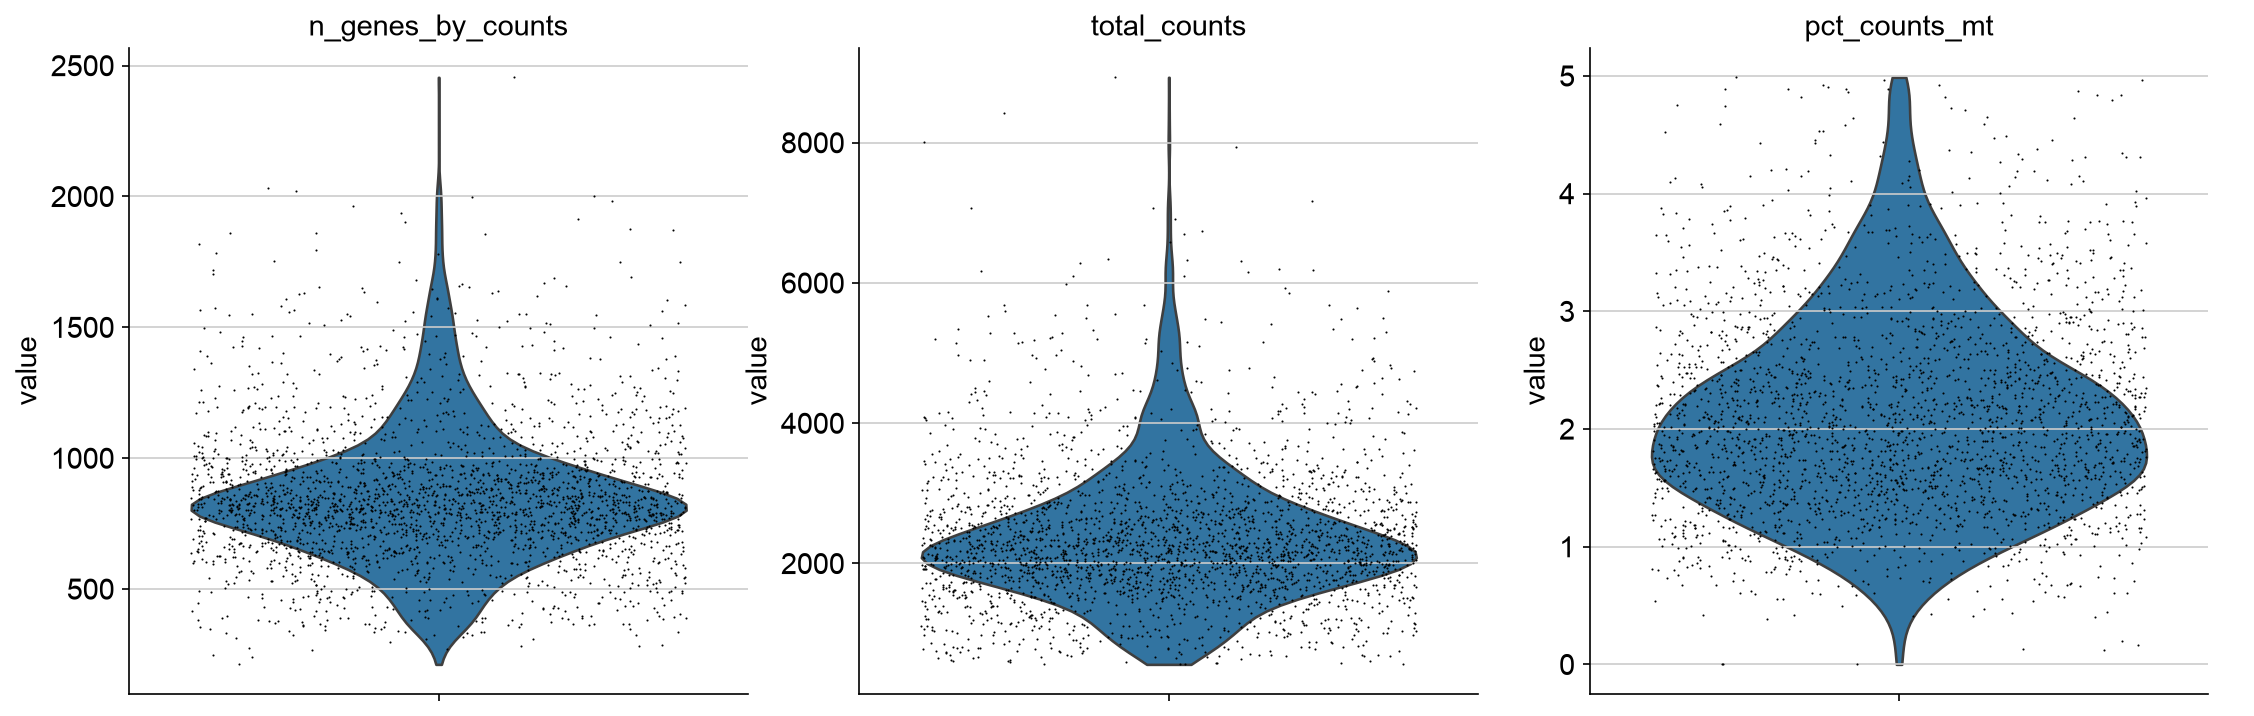

,0
n_cells_raw,2700.000000
n_cells_after_qc,2638.000000
n_genes_after_qc,13656.000000
n_cells_removed,62.000000
median_genes_per_cell,820.000000
median_counts_per_cell,2214.000000
median_pct_counts_mt,2.008619
qc_min_genes,200.000000
qc_max_genes,2500.000000
qc_max_mt_pct,5.000000


In [3]:
# QC metrics + filtering (defaults: min 200 genes, max 2500 genes, <5% mitochondrial)
adata = pl.run_qc(adata, OUTDIR)

display(Image("../results/figures/qc_violins_raw.png"))
display(Image("../results/figures/qc_violins_filtered.png"))
pd.read_csv("../results/tables/qc_metrics.tsv", sep="\t").T

## 3. Normalization and highly variable genes

Library sizes are scaled to a common target (10,000 counts) and log-transformed
(`log1p`), which makes expression values comparable across cells. To reduce
noise and computation, only the most variable genes are kept for the embedding
(Seurat-style mean/dispersion cutoffs).


normalizing counts per cell


    finished (0:00:01)


extracting highly variable genes


    finished (0:00:00)


--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


  wrote ../results/tables/hvg_genes.tsv


  wrote ../results/figures/hvg_dispersion.png


Normalization done: 1826 highly variable genes selected


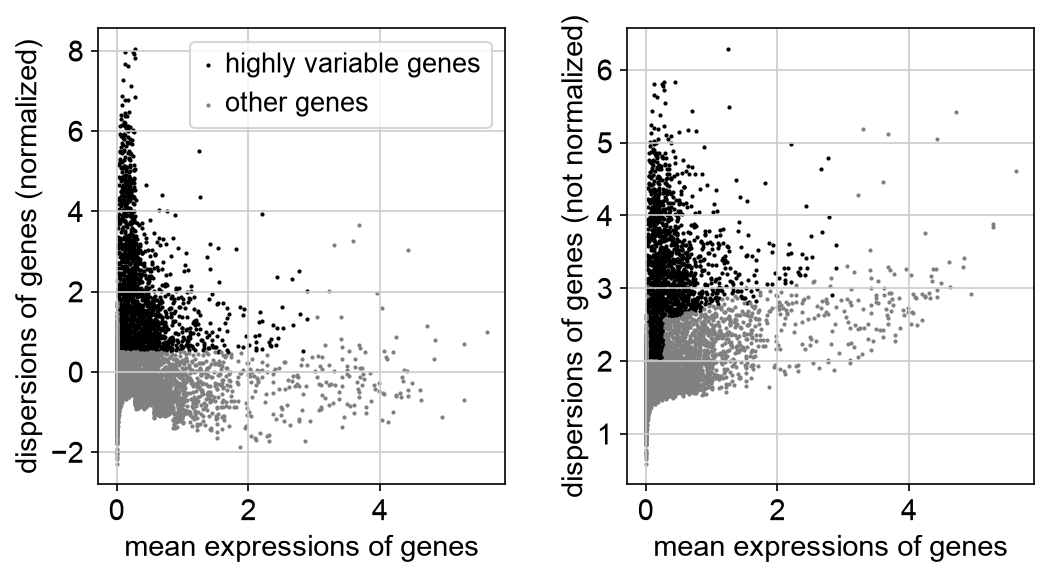

HVGs kept: 1,826 of 13,656 genes


In [4]:
adata = pl.run_normalize(adata, OUTDIR)
display(Image("../results/figures/hvg_dispersion.png"))
print(f"HVGs kept: {adata.n_vars:,} of {adata.raw.n_vars:,} genes")

## 4. Dimensionality reduction (PCA → kNN graph → UMAP)

The HVG matrix is projected onto its principal components (here 50), a
k-nearest-neighbour graph is built on the leading PCs, and UMAP embeds the graph
into two dimensions for visualization.


computing PCA


    with n_comps=50


    finished (0:00:00)


computing neighbors


    using 'X_pca' with n_pcs = 40


...

    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:02)


  wrote ../results/figures/pca_variance.png


  wrote ../results/figures/umap_total_counts.png


  wrote ../results/tables/pca_variance_ratio.tsv


Dimensionality reduction done: 50 PCs, 10 neighbors


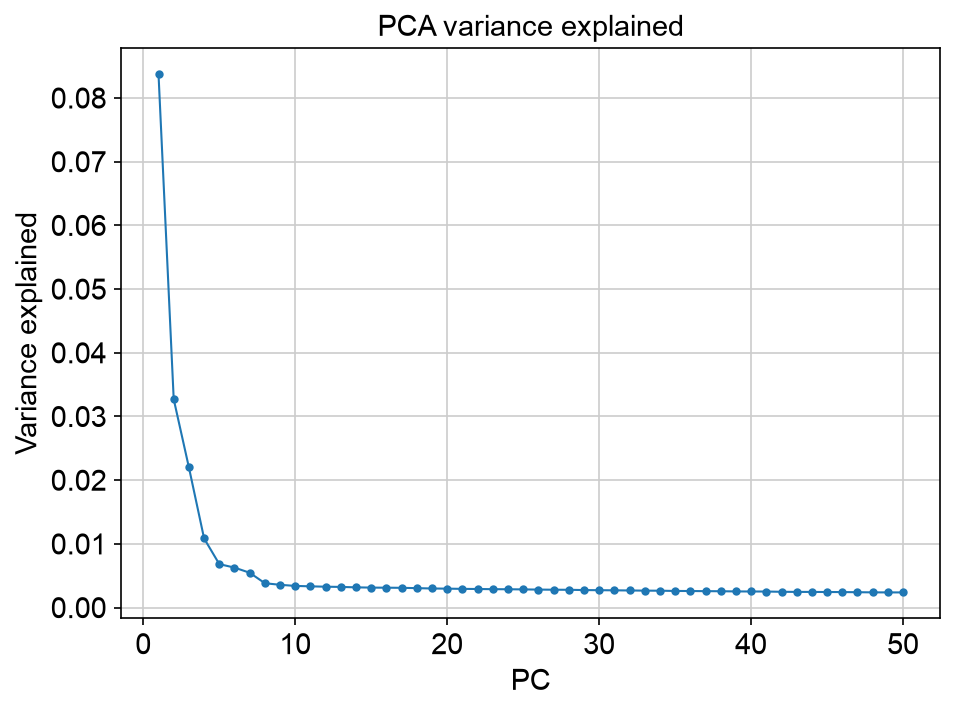

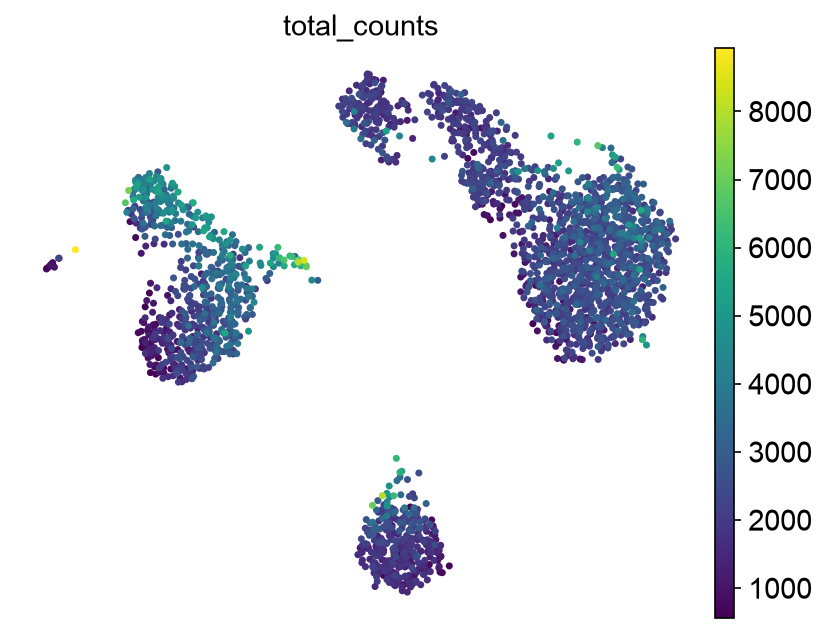

In [5]:
adata = pl.run_reduce(adata, OUTDIR)
display(Image("../results/figures/pca_variance.png"))
display(Image("../results/figures/umap_total_counts.png"))

## 5. Clustering and marker genes

Leiden clustering on the kNN graph partitions the cells into discrete groups;
differential expression (Wilcoxon rank-sum) then identifies the genes that
define each cluster.


running Leiden clustering


    finished: found 9 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


ranking genes


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:01)


  wrote ../results/tables/marker_genes.tsv


  wrote ../results/figures/umap_leiden.png


  wrote ../results/figures/marker_heatmap_top5.png


  wrote ../results/tables/multiqc_scanpy_markers_mqc.json


Clustering done: 9 Leiden clusters at resolution 0.8


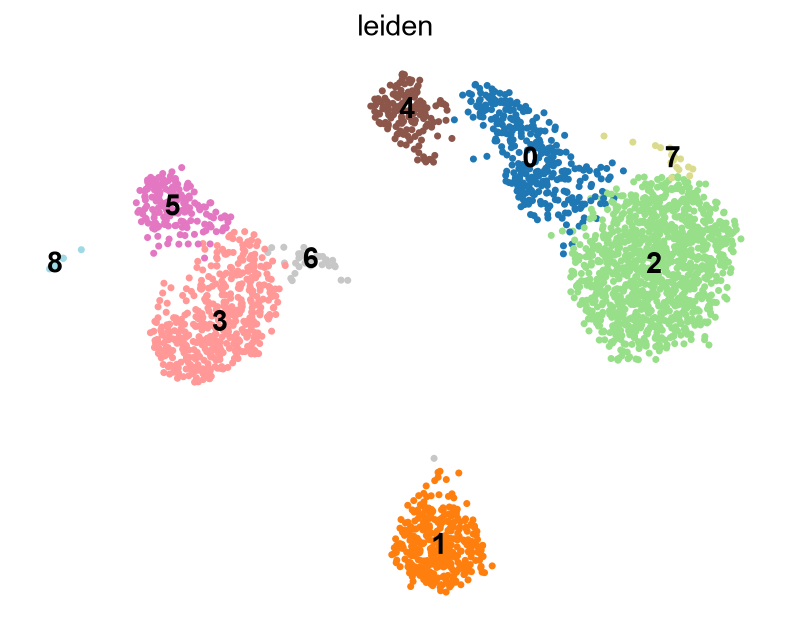

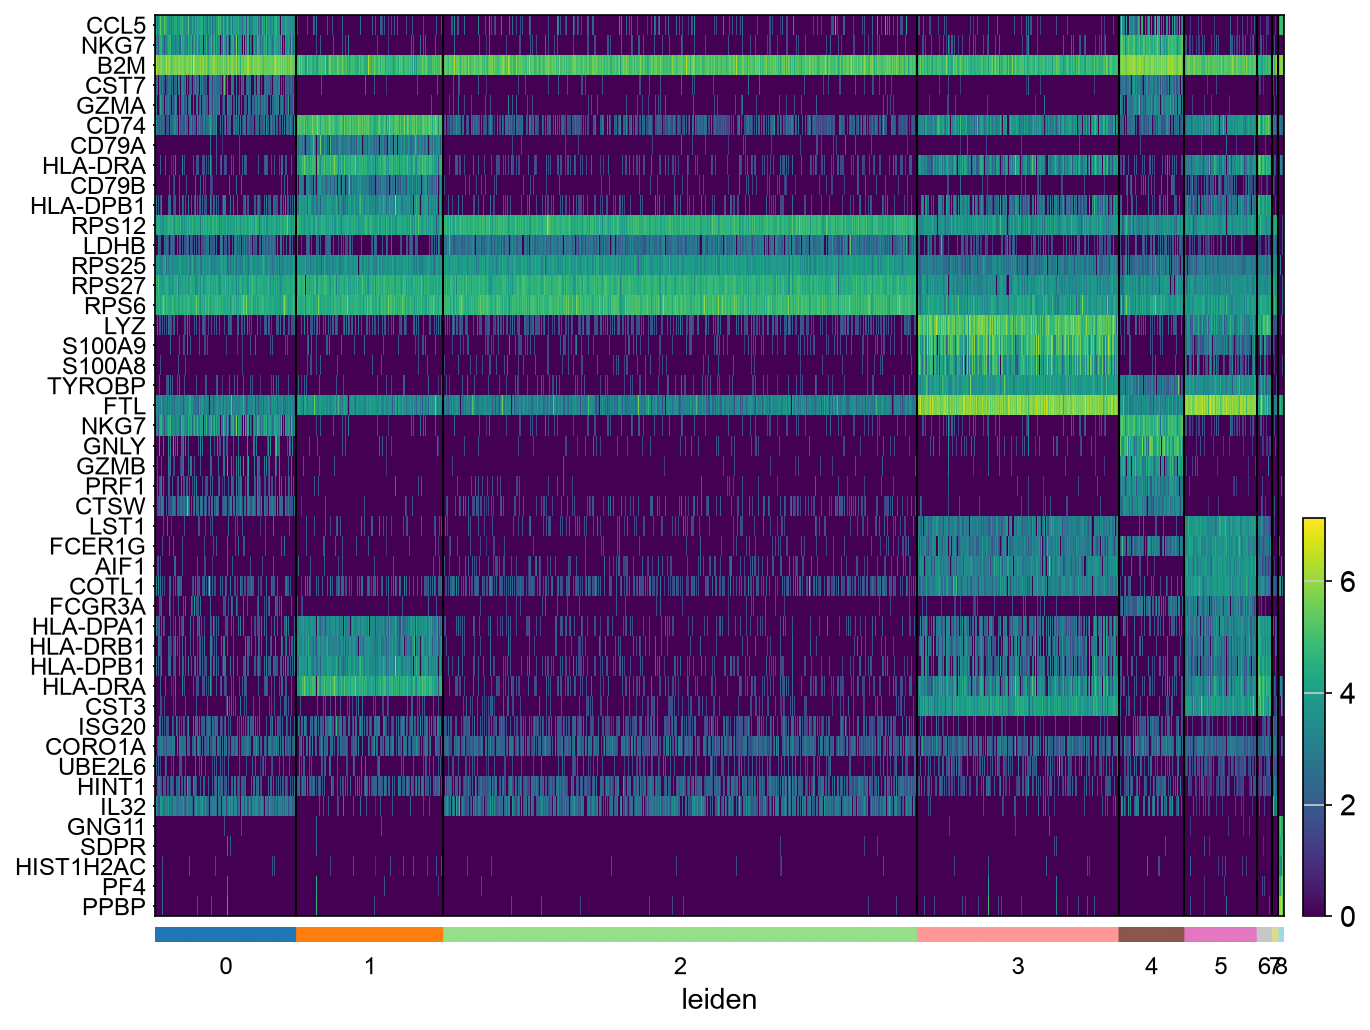

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,0,CCL5,27.113749,5.956467,6.779694e-162,9.258349e-158,0.990881,0.220442
1,0,NKG7,23.566390,5.100721,8.526726e-123,5.822049e-119,0.939210,0.207449
2,0,B2M,19.512310,0.766218,8.629392e-85,3.928099e-81,1.000000,0.999567
3,0,CST7,19.094175,4.225408,2.822837e-81,9.637166e-78,0.750760,0.117367
4,0,GZMA,19.082376,4.147006,3.538038e-81,9.663089e-78,0.759878,0.117367
5,0,CTSW,18.610394,3.322934,2.646698e-77,6.023884e-74,0.802432,0.227804
6,0,IL32,18.532406,2.675719,1.131143e-76,2.206698e-73,0.951368,0.495453
7,0,HLA-C,16.982958,0.951005,1.098087e-64,1.874435e-61,0.996960,0.979212
8,0,HLA-A,15.243070,0.942080,1.830641e-52,2.777693e-49,0.993921,0.961455
9,0,CD3D,15.229956,2.188604,2.237433e-52,3.055439e-49,0.887538,0.467735


In [6]:
adata = pl.run_cluster(adata, OUTDIR)
display(Image("../results/figures/umap_leiden.png"))
display(Image("../results/figures/marker_heatmap_top5.png"))

markers = pd.read_csv("../results/tables/marker_genes.tsv", sep="\t")
markers.head(10)

## 6. Cell-type annotation

Each Leiden cluster is scored against curated marker panels for the major PBMC
populations (using mean log-normalized expression of the panel genes). The
best-scoring panel labels the cluster; the score gap to the runner-up is a
simple confidence measure.


  wrote ../results/tables/celltype_proportions.tsv


  wrote ../results/tables/celltype_annotation.tsv


  wrote ../results/figures/umap_celltype.png


  wrote ../results/figures/dotplot_markers.png


  wrote ../results/tables/multiqc_scanpy_celltypes_mqc.json


Annotation done: CD4 T cells n=1108, CD14+ monocytes n=471, CD8 T cells n=345, B cells n=344, FCGR3A+ monocytes n=169, NK cells n=154, Dendritic cells n=35, Platelets n=12


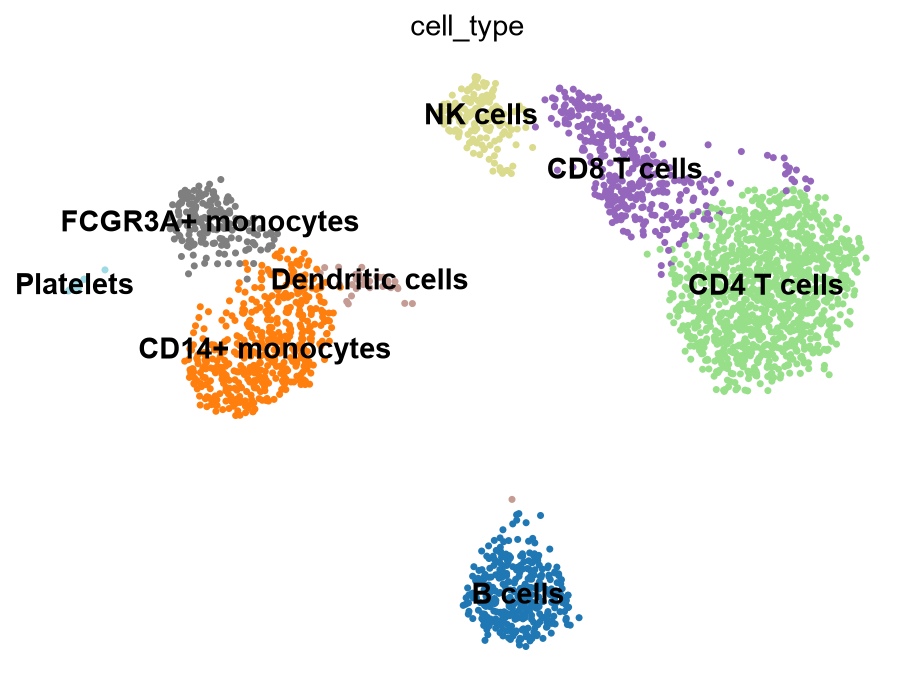

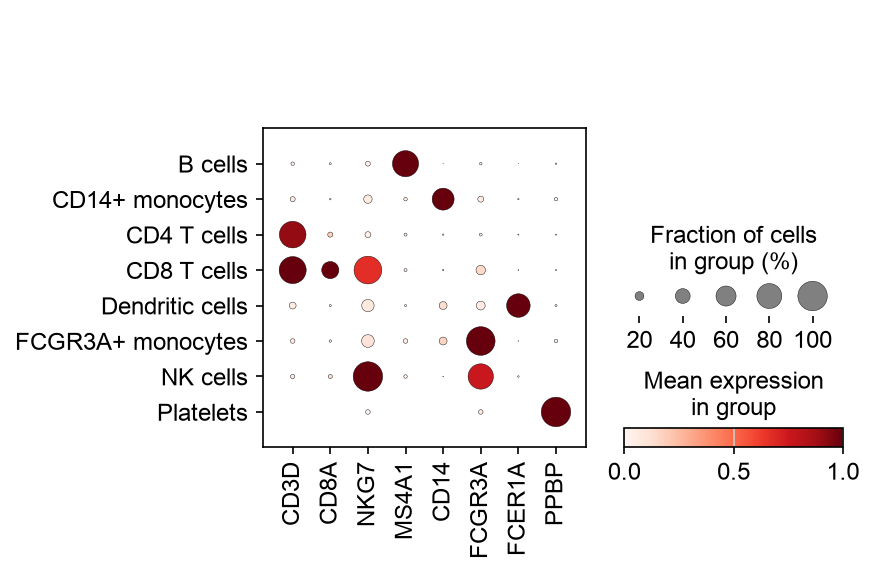

,cell_type,n_cells,fraction
0,CD4 T cells,1108,0.4200
1,CD14+ monocytes,471,0.1785
2,CD8 T cells,345,0.1308
3,B cells,344,0.1304
4,FCGR3A+ monocytes,169,0.0641
5,NK cells,154,0.0584
6,Dendritic cells,35,0.0133
7,Platelets,12,0.0045


In [7]:
adata = pl.run_annotate(adata, OUTDIR)
display(Image("../results/figures/umap_celltype.png"))
display(Image("../results/figures/dotplot_markers.png"))

composition = pd.read_csv("../results/tables/celltype_proportions.tsv", sep="\t")
annotation = pd.read_csv("../results/tables/celltype_annotation.tsv", sep="\t")
composition

In [8]:
annotation

,cluster,cell_type,top_score,second_best,score_gap
0,0,CD8 T cells,1.879,CD4 T cells,0.930
1,1,B cells,1.797,Dendritic cells,0.596
2,2,CD4 T cells,1.129,CD8 T cells,0.309
3,3,CD14+ monocytes,3.669,FCGR3A+ monocytes,2.094
4,4,NK cells,2.424,FCGR3A+ monocytes,1.723
5,5,FCGR3A+ monocytes,2.847,CD14+ monocytes,0.731
6,6,Dendritic cells,2.743,CD14+ monocytes,0.685
7,7,CD8 T cells,1.190,CD4 T cells,0.093
8,8,Platelets,4.673,CD8 T cells,3.886


## 7. Biological interpretation (summary)

After QC (2,700 → 2,638 cells, 2.3% removed), normalization and Leiden
clustering (resolution 0.8), the PBMC3k dataset resolves into **9 clusters that
collapse onto the 8 canonical peripheral-blood populations** of a healthy donor
(CD8 T cells are split into two clusters):

| Cell type | Cells | Fraction |
|---|---:|---:|
| CD4 T cells | 1,108 | 42.0% |
| CD14+ (classical) monocytes | 471 | 17.9% |
| CD8 T cells | 345 | 13.1% |
| B cells | 344 | 13.0% |
| FCGR3A+ (non-classical) monocytes | 169 | 6.4% |
| NK cells | 154 | 5.8% |
| Dendritic cells | 35 | 1.3% |
| Platelets (contaminating) | 12 | 0.5% |

**Key biological points**

1. **Composition matches a healthy donor.** T cells dominate (~55% CD4+CD8
   combined), followed by monocytes (~24% when both subsets are pooled), then B
   cells and NK cells; dendritic cells are rare (~1–2%). These proportions are
   the expected PBMC profile, which is reassuring for a QC sanity check.
2. **Marker-gene validation.** Every annotated population expresses its
   canonical markers: `CD3D`/`CD3E` (T cells), `CD8A`/`CD8B` (cytotoxic T),
   `NKG7`/`GNLY`/`KLRD1` (NK), `MS4A1`/`CD79A`/`CD79B` (B), `CD14`/`LYZ`/`S100A8`
   (classical monocytes), `FCGR3A`/`MS4A7` (non-classical monocytes),
   `FCER1A`/`CLEC10A` (dendritic cells), `PPBP`/`PF4` (platelets).
3. **QC decisions matter.** The mitochondrial-fraction (<5%) and gene-count
   filters removed 62 low-quality cells; the 12-cell platelet cluster is the
   well-known technical contamination of droplet scRNA-seq (platelet mRNA in
   the plasma fraction), not a true cell population.
4. **Clustering granularity is a trade-off.** At resolution 0.5 the rare
   dendritic cells merge into the monocyte cluster (they share the myeloid
   program, e.g. `LYZ`/`CST3`); resolution 0.8 separates them at the cost of a
   small extra CD8 T subdivision. This illustrates why cluster resolution must
   be tuned to the biological question.

**Caveats.** Annotation here is curated marker-panel scoring — fast and
transparent, but a proxy. A production analysis would add doublet detection
(e.g. Scrublet), reference-based label transfer (e.g. scArches/scANVI), and
finer subtype calls (e.g. naive vs. memory CD4 T cells via `CCR7`/`SELL` vs.
`S100A4`).


## Reproducibility

* **Script:** `analysis/pbmc3k_scanpy.py` — one entry point, five independent steps (`--step qc|normalize|reduce|cluster|annotate`).
* **Pipeline:** `nextflow/main.nf` orchestrates the steps as processes (Docker + MultiQC).
* **Environment:** pinned versions in `docker/requirements.txt` / `environment.yml`.
* **Session info:** exact package versions used to produce this notebook:


In [9]:
import warnings
warnings.filterwarnings("ignore")   # silence cosmetic FutureWarnings
import session_info
session_info.show()